 ## 1. Introduction

### Project Context

HealthConnect Clinic maintains appointment records containing patient, appointment, reminder, and attendance information. This analysis aims to understand appointment attendance and no-show patterns and identify factors associated with missed appointments.

The analysis focuses on appointment characteristics, patient history, reminder activity, waiting time, distance to the clinic, and appointment outcomes. Findings will support KPI development and evidence-based recommendations for improving appointment management and attendance.

### Business Questions

The initial analysis will be guided by the following business questions:

1. How does appointment attendance vary across reminder channels and appointments where no reminder was sent?
2. How is previous no-show behaviour associated with current appointment outcomes?
3. Which days of the week and time periods have the highest appointment volumes?
4. How is waiting time associated with appointment outcomes?
5. What proportion of appointments did not receive a reminder?
6. Does appointment type influence appointment outcomes?

## 2. Environment Setup

In [43]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
DATA_PATH = "data/HealthConnect_Appointment_Data.csv"

df = pd.read_csv(DATA_PATH)

## 3. Data Preparation and Quality Assessment

### Dataset Overview

In [17]:
df.head()

,appointment_id,patient_id,gender,age,age_group,appointment_type,booking_date,appointment_date,appointment_day,appointment_time,booking_lead_days,previous_appointments,previous_no_shows,reminder_sent,reminder_channel,distance_to_clinic_km,waiting_time_minutes,appointment_outcome
0,HC-00001,P-1613,Female,39,35-44,Follow-up,2/6/2025,2/18/2025,Tuesday,Afternoon,12,2,0,Yes,WhatsApp,19.3,29.0,No-Show
1,HC-00002,P-0813,Male,31,25-34,Specialist Consultation,2/25/2026,2/27/2026,Friday,Morning,2,6,0,Yes,SMS,14.3,42.0,Attended
2,HC-00003,P-1366,Female,50,45-54,General Consultation,11/16/2025,12/24/2025,Wednesday,Morning,38,5,1,Yes,SMS,11.4,11.0,No-Show
3,HC-00004,P-1031,Male,59,55-64,Follow-up,7/18/2025,8/28/2025,Thursday,Evening,41,3,1,Yes,SMS,7.4,35.0,Attended
4,HC-00005,P-1458,Female,34,25-34,Follow-up,7/9/2025,8/25/2025,Monday,Afternoon,47,3,1,Yes,Email,5.6,27.0,No-Show


#### Dataset Scope
The appointment dataset contains information relating to:

- Patient demographics
- Appointment details
- Booking information
- Previous appointment history
- Previous no-shows
- Reminder information
- Distance to the clinic
- Waiting time
- Appointment outcomes


#### Dataset Structure

In [5]:
# rows and columns
print(f"Rows: {df.shape[0]}")
print(f"Columns: {df.shape[1]}")

Rows: 5000
Columns: 18


### Data Types

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 18 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   appointment_id         5000 non-null   object 
 1   patient_id             5000 non-null   object 
 2   gender                 5000 non-null   object 
 3   age                    5000 non-null   int64  
 4   age_group              5000 non-null   object 
 5   appointment_type       5000 non-null   object 
 6   booking_date           5000 non-null   object 
 7   appointment_date       5000 non-null   object 
 8   appointment_day        5000 non-null   object 
 9   appointment_time       5000 non-null   object 
 10  booking_lead_days      5000 non-null   int64  
 11  previous_appointments  5000 non-null   int64  
 12  previous_no_shows      5000 non-null   int64  
 13  reminder_sent          5000 non-null   object 
 14  reminder_channel       3634 non-null   object 
 15  dist

### Missing Values

In [11]:
df.isna().sum()

appointment_id              0
patient_id                  0
gender                      0
age                         0
age_group                   0
appointment_type            0
booking_date                0
appointment_date            0
appointment_day             0
appointment_time            0
booking_lead_days           0
previous_appointments       0
previous_no_shows           0
reminder_sent               0
reminder_channel         1366
distance_to_clinic_km      90
waiting_time_minutes       60
appointment_outcome         0
dtype: int64

#### Distance to clinic and Waiting time in minutes distribution by appointment outcome

In [16]:
df[df["reminder_channel"]== "None"]

,appointment_id,patient_id,gender,age,age_group,appointment_type,booking_date,appointment_date,appointment_day,appointment_time,booking_lead_days,previous_appointments,previous_no_shows,reminder_sent,reminder_channel,distance_to_clinic_km,waiting_time_minutes,appointment_outcome,distance_missing,waiting_missing


In [11]:
df["distance_missing"] = df["distance_to_clinic_km"].isna()
df["waiting_missing"] = df["waiting_time_minutes"].isna()

df.groupby("distance_missing")["appointment_outcome"].value_counts(normalize=True)

distance_missing  appointment_outcome
False             No-Show                0.483910
                  Attended               0.463340
                  Cancelled              0.052749
True              No-Show                0.522222
                  Attended               0.433333
                  Cancelled              0.044444
Name: proportion, dtype: float64

In [12]:
df.groupby("waiting_missing")["appointment_outcome"].value_counts(normalize=True)

waiting_missing  appointment_outcome
False            No-Show                0.482996
                 Attended               0.464170
                 Cancelled              0.052834
True             No-Show                0.616667
                 Attended               0.350000
                 Cancelled              0.033333
Name: proportion, dtype: float64

### Duplicate Records

In [9]:
print("Duplicate rows:", df.duplicated().sum())
print("Duplicate appointment IDs:", df["appointment_id"].duplicated().sum())

Duplicate rows: 0
Duplicate appointment IDs: 0


### Categorical Consistency

In [10]:
categorical_cols = [
    "gender",
    "age_group",
    "appointment_type",
    "appointment_day",
    "appointment_time",
    "reminder_sent",
    "reminder_channel",
    "appointment_outcome"
]

for col in categorical_cols:
    print(f"\n{col}")
    print(df[col].value_counts(dropna=False))


gender
gender
Female               2488
Male                 2404
Prefer not to say     108
Name: count, dtype: int64

age_group
age_group
65+      1241
35-44     819
55-64     800
45-54     793
25-34     783
18-24     564
Name: count, dtype: int64

appointment_type
appointment_type
General Consultation       2086
Follow-up                  1421
Specialist Consultation     900
Diagnostic Test             593
Name: count, dtype: int64

appointment_day
appointment_day
Wednesday    737
Sunday       737
Friday       728
Saturday     724
Monday       701
Tuesday      689
Thursday     684
Name: count, dtype: int64

appointment_time
appointment_time
Morning      2227
Afternoon    2094
Evening       679
Name: count, dtype: int64

reminder_sent
reminder_sent
Yes    3634
No     1366
Name: count, dtype: int64

reminder_channel
reminder_channel
SMS         2000
NaN         1366
WhatsApp    1101
Email        533
Name: count, dtype: int64

appointment_outcome
appointment_outcome
No-Show      2423
A

### Check previous no-shows does not exceed previous appointments

In [ ]:

df[df["previous_no_shows"] > df["previous_appointments"]]

### Reminder Channel Validity

In [7]:
pd.crosstab(
    df["reminder_sent"],
    df["reminder_channel"],
    dropna=False
)

reminder_channel,Email,SMS,WhatsApp,NaN
reminder_sent,,,,
No,0,0,0,1366
Yes,533,2000,1101,0


#### Recode nan reminder channel to "No reminder"

In [19]:
df["reminder_channel"] = df["reminder_channel"].fillna("No reminder")

# confirmation
df["reminder_channel"].value_counts(dropna=False)

reminder_channel
SMS            2000
No reminder    1366
WhatsApp       1101
Email           533
Name: count, dtype: int64

### Date Validity

In [8]:
# formatted date fields to correct data type
df["booking_date"] = pd.to_datetime(df["booking_date"])
df["appointment_date"] = pd.to_datetime(df["appointment_date"])

(df["appointment_date"] < df["booking_date"]).sum()

(df["previous_no_shows"] < 0).sum()
(df["previous_appointments"] < 0).sum()
(df["booking_lead_days"] < 0).sum()
(df["waiting_time_minutes"] < 0).sum()
(df["distance_to_clinic_km"] < 0).sum()

np.int64(0)

### Data Quality Observation
- `reminder_channel` contains `SMS`, `WhatsApp`, and `Email`, with `None` values representing appointments where no reminder was sent; these were recoded as `No reminder` for analysis.
- `distance_to_clinic_km` has 90 missing values (1.8%), while `waiting_time_minutes` has 60 (1.2%). The data dictionary identifies these as limited missing values.
- Missing waiting-time records show a higher No-Show proportion (61.7%) than records with available waiting-time data (48.3%); this will be considered when interpreting related findings.
- Booking and appointment dates were converted from object to datetime for time-based analysis.
- Categorical values were consistent, and no duplicate records were identified.

## 4. Exploratory Data Analysis

### Appointment Outcomes

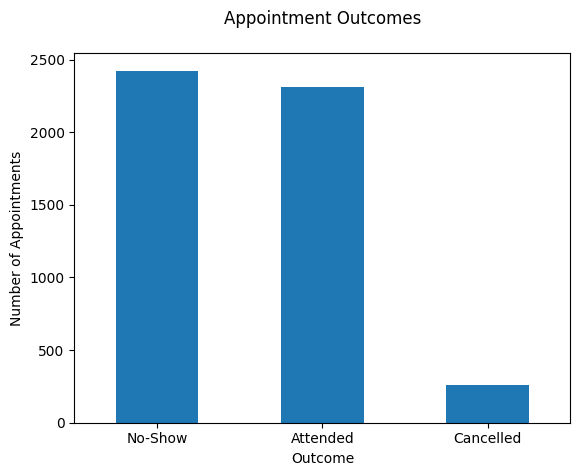

In [29]:
outcomes = df["appointment_outcome"].value_counts()
outcomes.plot(kind="bar")

plt.title("Appointment Outcomes\n")
plt.xlabel("Outcome")
plt.ylabel("Number of Appointments")
plt.xticks(rotation=0)
plt.show()

### Reminder Channels and Attendance

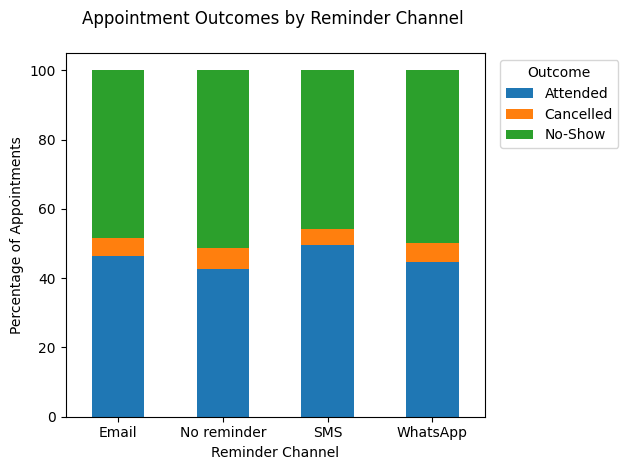

In [40]:
reminder_outcome = pd.crosstab(
    df["reminder_channel"],
    df["appointment_outcome"],
    normalize="index"
) * 100

reminder_outcome.plot(
    kind="bar",
    stacked=True
)

plt.title("Appointment Outcomes by Reminder Channel \n")
plt.xlabel("Reminder Channel")
plt.ylabel("Percentage of Appointments")
plt.xticks(rotation=0)
plt.legend(
    title="Outcome",
    loc="upper left",
    bbox_to_anchor=(1.02, 1)
)
plt.tight_layout()
plt.show()

### Previouse no-shows

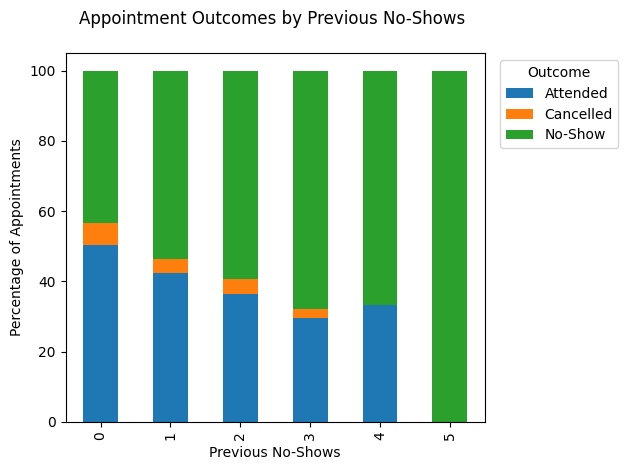

In [42]:
previous_outcome = pd.crosstab(
    df["previous_no_shows"],
    df["appointment_outcome"],
    normalize="index"
) * 100

previous_outcome.plot(
    kind="bar",
    stacked=True
)

plt.title("Appointment Outcomes by Previous No-Shows \n")
plt.xlabel("Previous No-Shows")
plt.ylabel("Percentage of Appointments")
plt.legend(
    title="Outcome",
    loc="upper left",
    bbox_to_anchor=(1.02, 1)
)
plt.tight_layout()
plt.show()

### Temporal Appointment Patterns

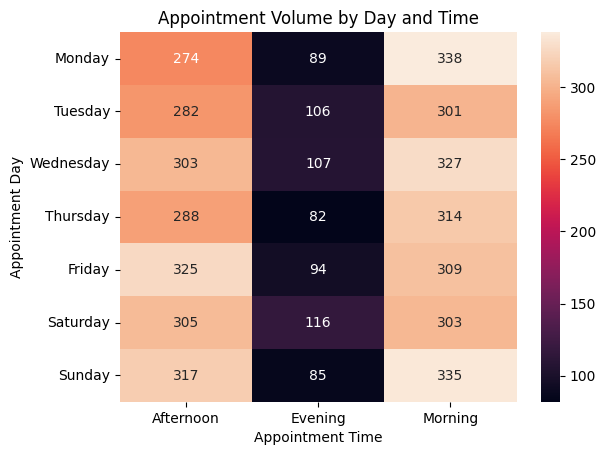

In [ ]:
day_order = [
    "Monday", "Tuesday", "Wednesday",
    "Thursday", "Friday", "Saturday", "Sunday"
]

day_time = pd.crosstab(
    df["appointment_day"],
    df["appointment_time"]
).reindex(day_order)

sns.heatmap(day_time, annot=True, fmt="d")

plt.title("Appointment Volume by Day and Time\n")
plt.xlabel("Appointment Time")
plt.ylabel("Appointment Day")
plt.show()

### Waiting Time

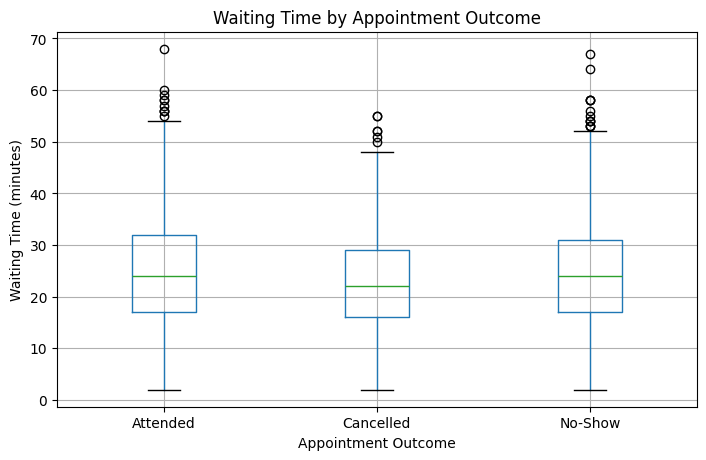

In [ ]:
df.boxplot(
    column="waiting_time_minutes",
    by="appointment_outcome",
    figsize=(8, 5)
)

plt.title("Waiting Time by Appointment Outcome\n")
plt.suptitle("")
plt.xlabel("Appointment Outcome")
plt.ylabel("Waiting Time (minutes)")
plt.show()

### Appointment Outcomes by Appointment Type

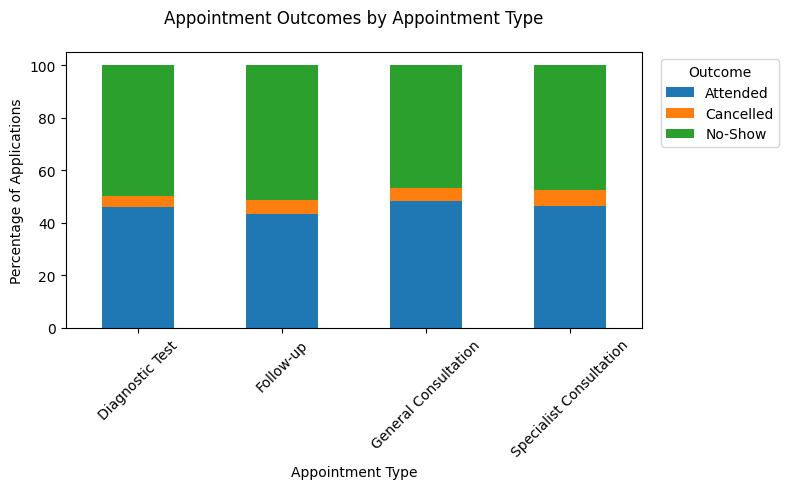

In [53]:
appointment_types_outcomes = pd.crosstab(
    df["appointment_type"],
    df["appointment_outcome"],
    normalize="index"
) * 100

appointment_types_outcomes.plot(
    kind="bar",
    stacked=True,
    figsize=(8,5)
)


plt.title("Appointment Outcomes by Appointment Type\n")
plt.xlabel("Appointment Type")
plt.ylabel("Percentage of Applications")
plt.xticks(rotation=45)
plt.legend(
    title="Outcome",
    loc="upper left",
    bbox_to_anchor=(1.02, 1)
)
plt.tight_layout()
plt.show()

### Patient characteristics — Age group

In [55]:
pd.crosstab(
    df["age_group"],
    df["appointment_outcome"],
    normalize="index"
).mul(100).round(2)

appointment_outcome,Attended,Cancelled,No-Show
age_group,,,
18-24,45.57,4.26,50.18
25-34,45.08,4.21,50.70
35-44,45.67,5.98,48.35
45-54,46.03,5.93,48.05
55-64,45.00,4.25,50.75
65+,48.75,6.12,45.12


Appointment outcomes are relatively consistent across age groups, with no-show rates ranging from approximately 45% to 51%. The limited variation suggests that age group may not be a strong differentiator of appointment attendance in this dataset.

### Distance to clinic

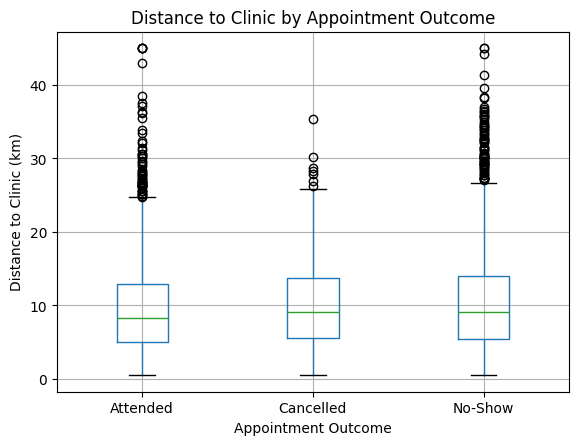

In [ ]:
df.boxplot(
    column="distance_to_clinic_km",
    by="appointment_outcome"
)

plt.title("Distance to Clinic by Appointment Outcome")
plt.suptitle("")
plt.xlabel("Appointment Outcome")
plt.ylabel("Distance to Clinic (km)")

plt.show()

## 5. KPI Development

## 6. Analytical Visualizations

## 7. Key Insights

## 8. Business Recommendations

## 9. Limitations

## 10. Conclusion